<a href="https://colab.research.google.com/github/Prasanthi-Peram/multiarm-bandits/blob/main/Multi_Arm_Bandit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Armed Bandit Problem

## 1. Problem Statement
The **$n$-armed bandit problem** involves choosing between $n$ different actions to maximize the total reward over time. Each action provides a reward from a stationary probability distribution.

## 2. Exploration vs Exploitation
- **Exploitation**: Choosing the best-known action to maximize immediate reward.
- **Exploration**: Choosing sub-optimal actions to improve estimates of their true values, potentially leading to higher long-term rewards.

## 3. 10-Armed Testbed
We evaluate algorithms using a 10-armed testbed where each arm's mean reward $q_*(a)$ is selected from a normal distribution $\mathcal{N}(0, 1)$. The actual reward received is $R_t \sim \mathcal{N}(q_*(a), 1)$.

## 4. Action-Value Method
We estimate the value of action $a$ at time $t$ using the **Sample Average** method:

$$Q_t(a) = \frac{\sum_{i=1}^{t-1} R_i \cdot \mathbb{1}_{A_i=a}}{\sum_{i=1}^{t-1} \mathbb{1}_{A_i=a}}$$

Where:
- $Q_t(a)$: Estimated value of action $a$ at time $t$.
- $R_i$: Reward received at time $i$.
- $\mathbb{1}_{A_i=a}$: **Indicator function** (1 if action $a$ was chosen at step $i$, 0 otherwise).
- The denominator represents the number of times action $a$ has been selected prior to time $t$.

In [28]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

class BanditTestbed:
    """10-armed bandit testbed problem"""
    def __init__(self, num_arms=10):
        self.num_arms = num_arms
        # Each arm's mean reward q*(a) is selected from N(0, 1)
        self.arm_means = np.random.normal(0, 1, num_arms)

    def pull_arm(self, arm):
        """Pull an arm and get reward from N(mean, 1)"""
        return np.random.normal(self.arm_means[arm], 1)

    def get_optimal_arm(self):
        """Return the index of the best arm"""
        return np.argmax(self.arm_means)

class BanditAgent:
    """Base class for all bandit algorithms"""
    def __init__(self, num_arms, initial_value=0.0):
        self.num_arms = num_arms
        self.Q = np.full(num_arms, initial_value, dtype=float)
        self.N = np.zeros(num_arms, dtype=int)
        self.t = 0

    def update(self, action, reward):
        """Update using incremental mean formula: Q(a) += (R - Q(a)) / N(a)"""
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]
        self.t += 1

    def select_action(self):
        raise NotImplementedError

def run_experiment(agent, testbed, steps=1000):
    rewards = []
    optimal = []
    best_arm = testbed.get_optimal_arm()
    for _ in range(steps):
        action = agent.select_action()
        reward = testbed.pull_arm(action)
        agent.update(action, reward)
        rewards.append(reward)
        optimal.append(action == best_arm)
    return np.array(rewards), np.array(optimal)

def run_multiple_experiments(agent_cls, kwargs, runs=2000, steps=1000):
    rewards = np.zeros((runs, steps))
    optimal = np.zeros((runs, steps))
    for i in range(runs):
        bandit = BanditTestbed()
        agent = agent_cls(10, **kwargs)
        r, o = run_experiment(agent, bandit, steps)
        rewards[i] = r
        optimal[i] = o
    return rewards.mean(0), optimal.mean(0) * 100

## 5. Greedy Algorithm
The greedy algorithm always selects the action with the highest estimated value:
$$A_t = \text{argmax}_a Q_t(a)$$

## 6. ̱-Greedy Algorithm
To ensure exploration, the ̱-greedy algorithm selects a random action with probability $\epsilon$, and the greedy action otherwise:
$$A_t = \begin{cases} \text{random action} & \text{with probability } \epsilon \\ \text{argmax}_a Q_t(a) & \text{with probability } 1-\epsilon \end{cases}$$

In [29]:
class GreedyAgent(BanditAgent):
    def select_action(self):
        best = np.flatnonzero(self.Q == self.Q.max())
        return np.random.choice(best)

class EpsilonGreedyAgent(BanditAgent):
    def __init__(self, num_arms, epsilon=0.1):
        super().__init__(num_arms)
        self.epsilon = epsilon

    def select_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.num_arms)
        best = np.flatnonzero(self.Q == self.Q.max())
        return np.random.choice(best)

runs, steps = 2000, 1000
greedy_r, greedy_o = run_multiple_experiments(GreedyAgent, {}, runs, steps)
eps_r, eps_o = run_multiple_experiments(EpsilonGreedyAgent, {"epsilon": 0.1}, runs, steps)

## 7. Optimistic Initial Values
By setting $Q_1(a) = +5$, the agent is initially disappointed by any arm it pulls, forcing it to explore all arms systematically until the estimates converge toward their true means.

## 8. Optimistic vs ̱-Greedy Figure
This plot compares the % Optimal Action for a Greedy agent with Optimistic initialization ($Q_1=5$) versus a standard e-Greedy agent ($Q_1=0, \epsilon=0.1$).

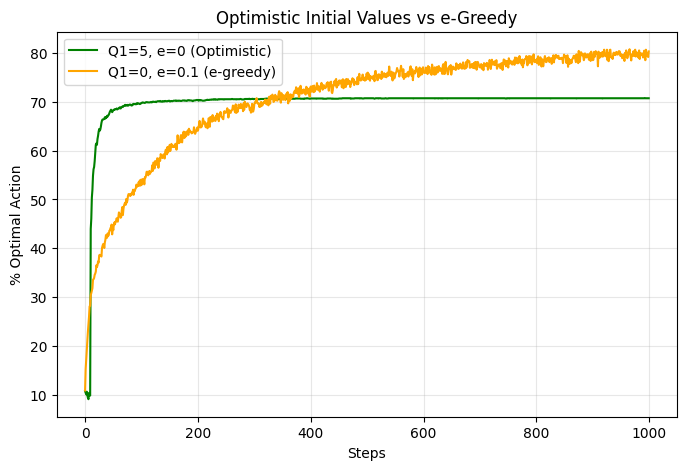

In [30]:
class OptimisticAgent(BanditAgent):
    def __init__(self, num_arms, initial_value=5.0):
        super().__init__(num_arms, initial_value)

    def select_action(self):
        best = np.flatnonzero(self.Q == self.Q.max())
        return np.random.choice(best)

# Run experiment
opt_r, opt_o = run_multiple_experiments(OptimisticAgent, {"initial_value": 5}, runs, steps)

plt.figure(figsize=(8, 5))
plt.plot(opt_o, label='Q1=5, e=0 (Optimistic)', color='green')
plt.plot(eps_o, label='Q1=0, e=0.1 (e-greedy)', color='orange')
plt.xlabel('Steps'); plt.ylabel('% Optimal Action')
plt.title('Optimistic Initial Values vs e-Greedy')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## 9. UCB Algorithm
Upper Confidence Bound (UCB) balances exploration by adding an uncertainty bonus to the value estimate:

$$A_t = \text{argmax}_a \left[ Q_t(a) + c \sqrt{\frac{\ln t}{N_t(a)}} \right]$$

Where:
- $c$: The confidence level (degree of exploration).
- $t$: The current time step.
- $N_t(a)$: The number of times action $a$ has been selected before time $t$.

In [31]:
class UCBAgent(BanditAgent):
    def __init__(self, num_arms, c=2.0):
        super().__init__(num_arms)
        self.c = c

    def select_action(self):
        if self.t < self.num_arms: return self.t
        ucb = self.Q + self.c * np.sqrt(np.log(self.t + 1) / self.N)
        return np.argmax(ucb)

ucb_r, ucb_o = run_multiple_experiments(UCBAgent, {"c": 2}, runs, steps)

## 10. Final Comparison
Average Reward and % Optimal Action for all strategies: Greedy, e-Greedy, Optimistic, and UCB.

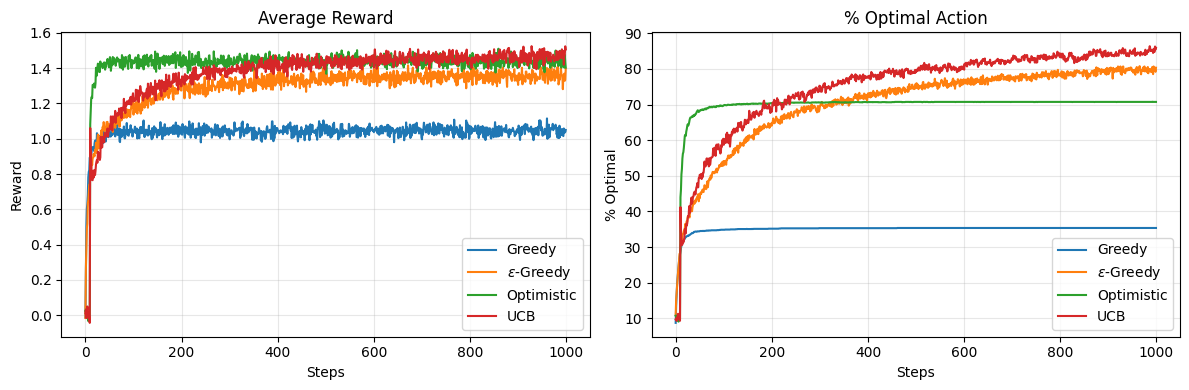

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
algos = [
    (greedy_r, greedy_o, 'Greedy'),
    (eps_r, eps_o, r'$\epsilon$-Greedy'),
    (opt_r, opt_o, 'Optimistic'),
    (ucb_r, ucb_o, 'UCB')
]
for r, o, label in algos:
    axes[0].plot(r, label=label)
    axes[1].plot(o, label=label)

axes[0].set_title('Average Reward')
axes[0].set_ylabel('Reward')
axes[1].set_title('% Optimal Action')
axes[1].set_ylabel('% Optimal')

for ax in axes:
    ax.set_xlabel('Steps')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()